In [ ]:
!pip install torch==2.0.1

In [ ]:
!nvidia-smi

In [ ]:
!pip install -q super-gradients==3.1.1
!pip install -q roboflow
!pip install -q supervision

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [ ]:
import torch

DEVICE = 'cuda' if torch.cuda.is_available() else "cpu"
MODEL_ARCH = 'yolo_nas_m'
print(DEVICE)

cuda


In [ ]:
!pip install --upgrade pillow==6.2.2

In [ ]:
from super_gradients import training

model = training.models.get(MODEL_ARCH, pretrained_weights="coco").to(DEVICE)

[2023-07-03 11:31:47] INFO - checkpoint_utils.py - License Notification: YOLO-NAS pre-trained weights are subjected to the specific license terms and conditions detailed in 
https://github.com/Deci-AI/super-gradients/blob/master/LICENSE.YOLONAS.md
By downloading the pre-trained weight files you agree to comply with these terms.


  0%|          | 0.00/73.1M [00:00<?, ?B/s]

Downloading: "https://sghub.deci.ai/models/yolo_nas_s_coco.pth" to /root/.cache/torch/hub/checkpoints/yolo_nas_s_coco.pth


In [ ]:
f"{HOME}/data"

'/content/data'

In [ ]:
%cd {HOME}
!mkdir {HOME}/data
%cd {HOME}/data

!wget -q https://media.roboflow.com/notebooks/examples/dog.jpeg
!wget -q https://media.roboflow.com/notebooks/examples/dog-2.jpeg
!wget -q https://media.roboflow.com/notebooks/examples/dog-3.jpeg
!wget -q https://media.roboflow.com/notebooks/examples/dog-4.jpeg
!wget -q https://media.roboflow.com/notebooks/examples/dog-5.jpeg
!wget -q https://media.roboflow.com/notebooks/examples/dog-6.jpeg
!wget -q https://media.roboflow.com/notebooks/examples/dog-7.jpeg
!wget -q https://media.roboflow.com/notebooks/examples/dog-8.jpeg

/content
/content/data


In [ ]:
SOURCE_IMAGE_PATH = f"{HOME}/data/dog-3.jpeg"

In [ ]:
import cv2

image = cv2.imread(SOURCE_IMAGE_PATH)
result = list(model.predict(image, conf=0.35))[0]
type(result)

super_gradients.training.models.prediction_results.ImageDetectionPrediction

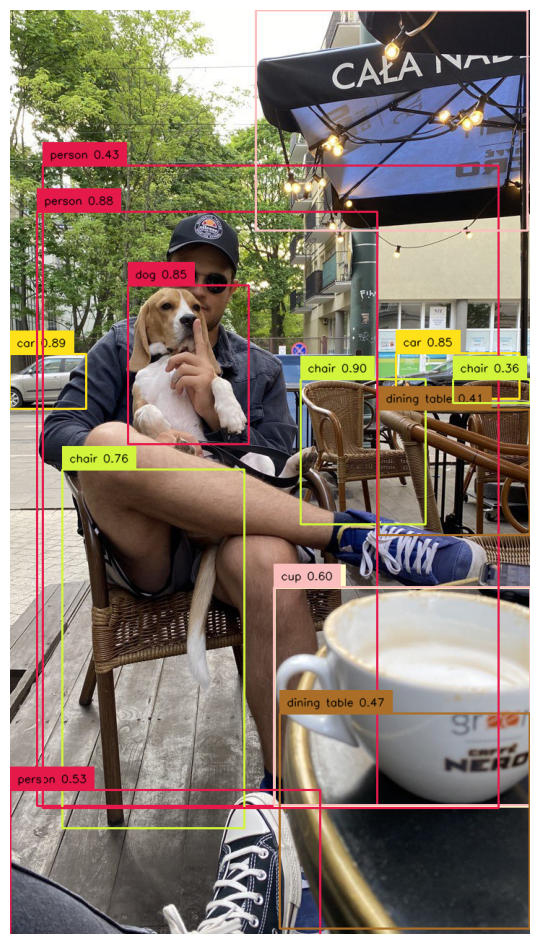

In [ ]:
import supervision as sv

detections = sv.Detections(
    xyxy=result.prediction.bboxes_xyxy,
    confidence=result.prediction.confidence,
    class_id=result.prediction.labels.astype(int)
)

box_annotator = sv.BoxAnnotator()

labels = [
    f"{result.class_names[class_id]} {confidence:0.2f}"
    for _, _, confidence, class_id, _
    in detections
]

annotated_frame = box_annotator.annotate(
    scene=image.copy(),
    detections=detections,
    labels=labels
)

%matplotlib inline
sv.plot_image(annotated_frame, (12, 12))

In [ ]:
MODEL_ARCH = 'yolo_nas_m' # m, l
BATCH_SIZE = 8
MAX_EPOCHS = 25
CHECKPOINT_DIR = f'{HOME}/checkpoints'
EXPERIMENT_NAME = 'first'

In [ ]:
from super_gradients.training import Trainer

trainer = Trainer(experiment_name=EXPERIMENT_NAME, ckpt_root_dir=CHECKPOINT_DIR)

In [ ]:
CLASSES = ["stop_sign","person","bicycle","bus","truck","car","motorbike","reflective_cone","ashcan","warning_column","spherical_roadblock","pole","dog","tricycle","fire_hydrant"]

In [ ]:
dataset_params = {
    'data_dir': '/content/drive/MyDrive/data1',
    'train_images_dir':'img-train',
    'train_labels_dir':'label-train',
    'val_images_dir':'img-val',
    'val_labels_dir':'label-val',
    'test_images_dir':'img-test',
    'test_labels_dir':'label-test',
    'classes': CLASSES
}

In [ ]:
from super_gradients.training.dataloaders.dataloaders import (
    coco_detection_yolo_format_train, coco_detection_yolo_format_val)

train_data = coco_detection_yolo_format_train(
    dataset_params={
        'data_dir': dataset_params['data_dir'],
        'images_dir': dataset_params['train_images_dir'],
        'labels_dir': dataset_params['train_labels_dir'],
        'classes': dataset_params['classes']
    },
    dataloader_params={
        'batch_size': BATCH_SIZE,
        'num_workers': 2
    }
)

Caching annotations: 100%|█████████▉| 5065/5066 [1:02:39<00:00,  1.48it/s]

In [ ]:
val_data = coco_detection_yolo_format_val(
    dataset_params={
        'data_dir': dataset_params['data_dir'],
        'images_dir': dataset_params['val_images_dir'],
        'labels_dir': dataset_params['val_labels_dir'],
        'classes': dataset_params['classes']
    },
    dataloader_params={
        'batch_size': BATCH_SIZE,
        'num_workers': 2
    }
)

Caching annotations: 100%|█████████▉| 1265/1266 [12:10<00:00,  1.57it/s]

In [ ]:
test_data = coco_detection_yolo_format_val(
    dataset_params={
        'data_dir': dataset_params['data_dir'],
        'images_dir': dataset_params['test_images_dir'],
        'labels_dir': dataset_params['test_labels_dir'],
        'classes': dataset_params['classes']
    },
    dataloader_params={
        'batch_size': BATCH_SIZE,
        'num_workers': 2
    }
)

[2023-07-03 12:57:49] WARNING - yolo_format_detection.py - 11 label files are not associated to any image.
Caching annotations: 100%|█████████▉| 1582/1583 [23:53<00:00,  2.00it/s]

In [ ]:
train_data.dataset.transforms

In [ ]:
from super_gradients.training import models

model = models.get(
    MODEL_ARCH,
    num_classes=len(dataset_params['classes']),
    pretrained_weights="coco"
)

[2023-07-03 13:22:03] INFO - checkpoint_utils.py - License Notification: YOLO-NAS pre-trained weights are subjected to the specific license terms and conditions detailed in 
https://github.com/Deci-AI/super-gradients/blob/master/LICENSE.YOLONAS.md
By downloading the pre-trained weight files you agree to comply with these terms.


In [ ]:
from super_gradients.training.losses import PPYoloELoss
from super_gradients.training.metrics import DetectionMetrics_050
from super_gradients.training.models.detection_models.pp_yolo_e import PPYoloEPostPredictionCallback

In [ ]:
train_params = {
    'silent_mode': False,
    "average_best_models":True,
    "warmup_mode": "linear_epoch_step",
    "warmup_initial_lr": 1e-6,
    "lr_warmup_epochs": 3,
    "initial_lr": 5e-4,
    "lr_mode": "cosine",
    "cosine_final_lr_ratio": 0.1,
    "optimizer": "Adam",
    "optimizer_params": {"weight_decay": 0.0001},
    "zero_weight_decay_on_bias_and_bn": True,
    "ema": True,
    "ema_params": {"decay": 0.9, "decay_type": "threshold"},
    "max_epochs": MAX_EPOCHS,
    "mixed_precision": True,
    "loss": PPYoloELoss(
        use_static_assigner=False,
        num_classes=len(dataset_params['classes']),
        reg_max=16
    ),"valid_metrics_list": [
        DetectionMetrics_050(
            score_thres=0.1,
            top_k_predictions=300,
            num_cls=len(dataset_params['classes']),
            normalize_targets=True,
            post_prediction_callback=PPYoloEPostPredictionCallback(
                score_threshold=0.01,
                nms_top_k=1000,
                max_predictions=300,
                nms_threshold=0.7
            )
        )
    ],
    "metric_to_watch": 'mAP@0.50'
}

In [ ]:
trainer.train(
    model=model,
    training_params=train_params,
    train_loader=train_data,
    valid_loader=val_data
)

[2023-07-03 16:08:34] INFO - sg_trainer.py - Using EMA with params {'decay': 0.9, 'decay_type': 'threshold'}


The console stream is now moved to /content/checkpoints/first/console_Jul03_16_08_34.txt


[2023-07-03 16:08:44] INFO - sg_trainer_utils.py - TRAINING PARAMETERS:
    - Mode:                         Single GPU
    - Number of GPUs:               1          (1 available on the machine)
    - Dataset size:                 5066       (len(train_set))
    - Batch size per GPU:           8          (batch_size)
    - Batch Accumulate:             1          (batch_accumulate)
    - Total batch size:             8          (num_gpus * batch_size)
    - Effective Batch size:         8          (num_gpus * batch_size * batch_accumulate)
    - Iterations per epoch:         633        (len(train_loader))
    - Gradient updates per epoch:   633        (len(train_loader) / batch_accumulate)

[2023-07-03 16:08:44] INFO - sg_trainer.py - Started training for 25 epochs (0/24)

Validation epoch 0: 100%|██████████| 159/159 [00:52<00:00,  3.00it/s]


SUMMARY OF EPOCH 0
├── Training
│   ├── Ppyoloeloss/loss = 2.2785
│   ├── Ppyoloeloss/loss_cls = 1.1081
│   ├── Ppyoloeloss/loss_dfl = 1.1643
│   └── Ppyoloeloss/loss_iou = 0.2353
└── Validation
    ├── F1@0.50 = 0.0649
    ├── Map@0.50 = 0.5267
    ├── Ppyoloeloss/loss = 2.0067
    ├── Ppyoloeloss/loss_cls = 1.0055
    ├── Ppyoloeloss/loss_dfl = 1.0031
    ├── Ppyoloeloss/loss_iou = 0.1999
    ├── Precision@0.50 = 0.0341
    └── Recall@0.50 = 0.8297



[2023-07-03 16:23:15] INFO - base_sg_logger.py - Checkpoint saved in /content/checkpoints/first/ckpt_best.pth
[2023-07-03 16:23:15] INFO - sg_trainer.py - Best checkpoint overriden: validation mAP@0.50: 0.5266597867012024
Validation epoch 1: 100%|██████████| 159/159 [00:50<00:00,  3.18it/s]


...

Validation epoch 3: 100%|██████████| 159/159 [00:53<00:00,  2.97it/s]


SUMMARY OF EPOCH 3
├── Training
│   ├── Ppyoloeloss/loss = 2.3569
│   │   ├── Best until now = 2.2029 (↗ 0.154)
│   │   └── Epoch N-1      = 2.2907 (↗ 0.0662)
│   ├── Ppyoloeloss/loss_cls = 1.1492
│   │   ├── Best until now = 1.0788 (↗ 0.0704)
│   │   └── Epoch N-1      = 1.1222 (↗ 0.027)
│   ├── Ppyoloeloss/loss_dfl = 1.2025
│   │   ├── Best until now = 1.1213 (↗ 0.0812)
│   │   └── Epoch N-1      = 1.1635 (↗ 0.039)
│   └── Ppyoloeloss/loss_iou = 0.2426
│       ├── Best until now = 0.2254 (↗ 0.0172)
│       └── Epoch N-1      = 0.2347 (↗ 0.0079)
└── Validation
    ├── F1@0.50 = 0.0602
    │   ├── Best until now = 0.0702 (↘ -0.0101)
    │   └── Epoch N-1      = 0.0587 (↗ 0.0014)
    ├── Map@0.50 = 0.4442
    │   ├── Best until now = 0.5381 (↘ -0.0939)
    │   └── Epoch N-1      = 0.5019 (↘ -0.0577)
    ├── Ppyoloeloss/loss = 2.2107
    │   ├── Best until now = 2.0067 (↗ 0.204)
    │   └── Epoch N-1      = 2.0651 (↗ 0.1456)
    ├── Ppyoloeloss/loss_cls = 1.1295
    │   ├── Best until no

Validation epoch 4: 100%|██████████| 159/159 [00:50<00:00,  3.12it/s]


SUMMARY OF EPOCH 4
├── Training
│   ├── Ppyoloeloss/loss = 2.3224
│   │   ├── Best until now = 2.2029 (↗ 0.1195)
│   │   └── Epoch N-1      = 2.3569 (↘ -0.0345)
│   ├── Ppyoloeloss/loss_cls = 1.1347
│   │   ├── Best until now = 1.0788 (↗ 0.0558)
│   │   └── Epoch N-1      = 1.1492 (↘ -0.0146)
│   ├── Ppyoloeloss/loss_dfl = 1.18
│   │   ├── Best until now = 1.1213 (↗ 0.0588)
│   │   └── Epoch N-1      = 1.2025 (↘ -0.0225)
│   └── Ppyoloeloss/loss_iou = 0.2391
│       ├── Best until now = 0.2254 (↗ 0.0137)
│       └── Epoch N-1      = 0.2426 (↘ -0.0035)
└── Validation
    ├── F1@0.50 = 0.0579
    │   ├── Best until now = 0.0702 (↘ -0.0123)
    │   └── Epoch N-1      = 0.0602 (↘ -0.0023)
    ├── Map@0.50 = 0.4993
    │   ├── Best until now = 0.5381 (↘ -0.0388)
    │   └── Epoch N-1      = 0.4442 (↗ 0.0551)
    ├── Ppyoloeloss/loss = 2.0772
    │   ├── Best until now = 2.0067 (↗ 0.0705)
    │   └── Epoch N-1      = 2.2107 (↘ -0.1334)
    ├── Ppyoloeloss/loss_cls = 1.0468
    │   ├── Best u

Validation epoch 5:  60%|██████    | 96/159 [00:31<00:20,  3.08it/s]

In [ ]:
!zip -r yolo_nas.zip {CHECKPOINT_DIR}/{EXPERIMENT_NAME}

In [ ]:
best_model = models.get(
    MODEL_ARCH,
    num_classes=len(dataset_params['classes']),
    checkpoint_path=f"{CHECKPOINT_DIR}/{EXPERIMENT_NAME}/average_model.pth"
).to(DEVICE)

In [ ]:
trainer.test(
    model=best_model,
    test_loader=test_data,
    test_metrics_list=DetectionMetrics_050(
        score_thres=0.1,
        top_k_predictions=300,
        num_cls=len(dataset_params['classes']),
        normalize_targets=True,
        post_prediction_callback=PPYoloEPostPredictionCallback(
            score_threshold=0.01,
            nms_top_k=1000,
            max_predictions=300,
            nms_threshold=0.7
        )
    )
)

In [ ]:
import supervision as sv

ds = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{dataset.location}/test/images",
    annotations_directory_path=f"{dataset.location}/test/labels",
    data_yaml_path=f"{dataset.location}/data.yaml",
    force_masks=False
)

In [ ]:
import supervision as sv

CONFIDENCE_TRESHOLD = 0.5

predictions = {}

for image_name, image in ds.images.items():
    result = list(best_model.predict(image, conf=CONFIDENCE_TRESHOLD))[0]
    detections = sv.Detections(
        xyxy=result.prediction.bboxes_xyxy,
        confidence=result.prediction.confidence,
        class_id=result.prediction.labels.astype(int)
    )
    predictions[image_name] = detections

In [ ]:
import random
random.seed(10)

In [ ]:
import supervision as sv

MAX_IMAGE_COUNT = 5

n = min(MAX_IMAGE_COUNT, len(ds.images))

keys = list(ds.images.keys())
keys = random.sample(keys, n)

box_annotator = sv.BoxAnnotator()

images = []
titles = []

In [ ]:
for key in keys:
    frame_with_annotations = box_annotator.annotate(
        scene=ds.images[key].copy(),
        detections=ds.annotations[key],
        skip_label=True
    )
    images.append(frame_with_annotations)
    titles.append('annotations')
    frame_with_predictions = box_annotator.annotate(
        scene=ds.images[key].copy(),
        detections=predictions[key],
        skip_label=True
    )
    images.append(frame_with_predictions)
    titles.append('predictions')

%matplotlib inline
sv.plot_images_grid(images=images, titles=titles, grid_size=(n, 2), size=(2 * 4, n * 4))

In [ ]:
!pip install onemetric

In [ ]:
import os

import numpy as np

from onemetric.cv.object_detection import ConfusionMatrix

keys = list(ds.images.keys())

annotation_batches, prediction_batches = [], []

In [ ]:
for key in keys:
    annotation=ds.annotations[key]
    annotation_batch = np.column_stack((
        annotation.xyxy,
        annotation.class_id
    ))
    annotation_batches.append(annotation_batch)

    prediction=predictions[key]
    prediction_batch = np.column_stack((
        prediction.xyxy,
        prediction.class_id,
        prediction.confidence
    ))
    prediction_batches.append(prediction_batch)

In [ ]:
confusion_matrix = ConfusionMatrix.from_detections(
    true_batches=annotation_batches,
    detection_batches=prediction_batches,
    num_classes=len(ds.classes),
    conf_threshold=CONFIDENCE_TRESHOLD
)

confusion_matrix.plot(os.path.join(HOME, "confusion_matrix.png"), class_names=ds.classes)